In [ ]:
# The goal of this notebook is to 
# identify features that we can remove
# to simplify our modeling. 

# Our approach will be to:
#  (1) identify weak correlations
#    between features and
#    radon concentraiton target.
#    Those will represent features
#    that continue little information
#    and can be justified in their removal
#  (2) identify features that have high
#    correlation with other features.
#    These represent redundant features.
#    That is features which hold the 
#    same information as others. These
#    can also be eliminated

In [148]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys
from pathlib import Path
from sklearn.feature_selection import mutual_info_classif

# define project root
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

# Get file location stuff
from src.data.data_loading import load_full_dataset

In [149]:
FEATURE_KEEP = []
FEATURE_DROP = []
FEATURE_REVIEW = []

In [150]:
# load the data
df = load_full_dataset()
df = df.copy()

# remove held-out test data
# df = df[~df["is_test"]].copy()

#print(df.head())

In [151]:
# Add log of Radon concentraiton
#   (radon concentraiton is approx. log-normal distributed)

df["log_concentration"] = np.log(df["concentration"])

In [152]:
# Build the Exceedance statistics per FSA 
#  This is some baseline verison of our target

RADON_CONC_HEALTH_RISK = 200

df["radon_danger_conc"] = (df["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)


# compute the fraction of houses exceeding the threshold within each FSA 
fsa_stats = (
    df.groupby("FSA")
      .agg(
          n_measurements=("concentration", "size"),
          mean_radon=("concentration", "mean"),
          mean_log_radon=("log_concentration", "mean"),
          frac_danger=("radon_danger_conc", "mean")
      )
      .reset_index()
)


# Make some baseline classification target measure

RISK_THRESHOLD = 0.10

fsa_stats["high_risk_fsa"] = (fsa_stats["frac_danger"] >= RISK_THRESHOLD).astype(int)

In [153]:
# At threshold = 0.10, the data is actually not super imbalanced!

fsa_stats["high_risk_fsa"].value_counts(normalize=True)

high_risk_fsa
0    0.706468
1    0.293532
Name: proportion, dtype: float64

In [ ]:
#  Now, we can *almost* look at some stuff!
#   We just need to do a little more 
#   data handling...  
#     - eliminate non-feature columns in the data
#     - impute NaN (this is justforr the uranium conc. data)

# Define the feature data

X = df.copy()

# Specify non-feature data
#  in the df columns 
#   see: jb_eda_validFeatures.ipynb for more information
basal_non_feature_columns = [
    "FSA",
    "n_days",
    "concentration",
    "provinceterritory",
    "geometry",
    "spatial_cluster",
    "is_test",
    "cv_fold",
]

# We just made non-feature data today...
local_non_feature_columns = [
    "log_concentration", 
    "radon_danger_conc",
]

#  Both of these form columns that represent non-features
non_feature_columns = basal_non_feature_columns + local_non_feature_columns


#  There are other columns that we should immediately drop from the data, too

# Some columns are parts of groups 
#   that add to 1 and therefore 
#   are not independent variables.
#   I call these compositional featuers
#   and i record one of them to be removed
compositional_columns_to_drop = [
    "hous_frac_type_movable",
    "hous_frac_age_1981_2000",
    "demogr_frac_tenure_rented",
]

# Some of the features are zero for every datapoint. 
#   These have no information content and should be dropped.
zero_valued_columns_to_drop = [
    "geolprov_arctic_continental_shelf", 
    "geolprov_arctic_platform", 
    "geolprov_bear_province", 
    "geolprov_innuitian_orogen", 
    "geolprov_slave_province", 
    "geolprov_oceanic_crust", 
    "sedi_weathered_bedrock_or_regolith",
]

non_informative_feature_columns = compositional_columns_to_drop + zero_valued_columns_to_drop


#  We build a list of all these together that should be dropped.
initial_columns_to_drop = non_feature_columns + non_informative_feature_columns


# Now that we have made our list
#  of non-features, we cut 'em out
X = X.drop(columns=initial_columns_to_drop)

# record dropped columns for posterity 
FEATURE_DROP +=initial_columns_to_drop

# Define the target data

y = df["radon_danger_conc"]



In [155]:
# For missing data, impute with median 
#  (this is basically only for Uranium data)

nan_counts = X.isna().sum().sort_values(ascending=False)
nan_counts[nan_counts > 0].head(20)
X = X.fillna(X.median())

Lowest variance features:
sedi_volcanic_deposits                      0.000010
geolprov_nain_province                      0.000042
sedi_glacial_ice_or_snowpack                0.000077
rxtp_sedimentary_and_volcanic_rocks         0.000199
geolprov_pacific_continental_shelf          0.000252
sedi_eolian_sediments                       0.000582
socioeco_frac_high_income                   0.000606
socioeco_frac_overcrowded                   0.000717
geolprov_unknown                            0.000763
geolprov_atlantic_continental_shelf         0.000858
geolprov_hudson_bay_lowlands                0.000923
socioeco_frac_unsuitable_housing            0.001363
sedi_organic_deposits                       0.001817
socioeco_frac_housing_burden                0.002052
sedi_colluvial_and_mass-wasting_deposits    0.002180
hous_frac_major_repair                      0.002410
socioeco_frac_low_income                    0.002537
socioeco_frac_unemployment_rate             0.002821
hous_frac_type_highr

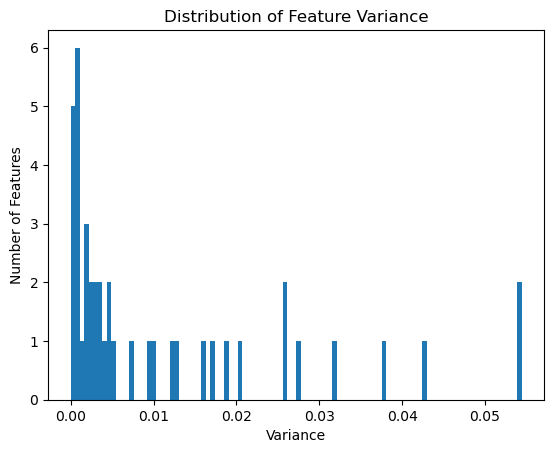

In [156]:
# Look at the variance of the data. 
#   Features with very low variance could be eliminated

from sklearn.feature_selection import VarianceThreshold

# Inspect variance before filtering
feature_variance = X.var().sort_values()

print("Lowest variance features:")
print(feature_variance.head(25))
print("Highest variance features:")
print(feature_variance.tail(5))



import matplotlib.pyplot as plt

feature_variance_trimmed = feature_variance.drop(
    feature_variance.nlargest(20).index
)
feature_variance_trimmed.plot(kind="hist", bins=100)
plt.title("Distribution of Feature Variance")
plt.xlabel("Variance")
plt.ylabel("Number of Features")
plt.show()




In [ ]:

# # Apply variance threshold
# variance_threshold = 0.01

# selector = VarianceThreshold(threshold=variance_threshold)

# X_var = selector.fit_transform(X)

# # Get remaining feature names
# selected_features = X.columns[selector.get_support()]

# # Convert back to dataframe for easier inspection
# X = pd.DataFrame(X_var, columns=selected_features, index=X.index)

# print("\nNumber of features before filtering:", len(feature_variance))
# print("Number of features after filtering:", len(selected_features))

# removed_features = feature_variance.index.difference(selected_features)

# print("\nRemoved low-variance features:")
# print(list(removed_features))

In [157]:
# Create a threshold for low vairnac efeatures and drop those...

LOW_VARIANCE_THRESHOLD = 0.0001

low_variance_features = feature_variance[
    feature_variance < LOW_VARIANCE_THRESHOLD
].index.tolist()

print(low_variance_features)

FEATURE_DROP += low_variance_features

['sedi_volcanic_deposits', 'geolprov_nain_province', 'sedi_glacial_ice_or_snowpack']


In [158]:
# START EVALUATING FEATURE REDUNDANCY
# check out magnitude of the correlations between features

corr = X.corr().abs()

# ignore duplicate Corr's
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# find weirdly big ones
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

print(len(to_drop), "features to drop")
print(to_drop)

4 features to drop
['hous_frac_type_other_attached', 'demogr_num_total_dwellings', 'demogr_num_occ_dwellings', 'socioeco_frac_unsuitable_housing']


In [ ]:
print(upper)

In [159]:
# Inspect correlated pairs
 
high_corr = (
    corr.stack()
        .reset_index()
)

high_corr.columns = ["feature1","feature2","corr"]

high_corr = high_corr[
    (high_corr["feature1"] != high_corr["feature2"]) &
    (high_corr["corr"] > 0.8)
]

high_corr.sort_values("corr", ascending=False).head(20)

,feature1,feature2,corr
632,demogr_pop_2016,demogr_num_occ_dwellings,0.981500
754,demogr_num_occ_dwellings,demogr_pop_2016,0.981500
694,demogr_num_total_dwellings,demogr_num_occ_dwellings,0.978219
755,demogr_num_occ_dwellings,demogr_num_total_dwellings,0.978219
1513,socioeco_frac_overcrowded,socioeco_frac_unsuitable_housing,0.969734
1574,socioeco_frac_unsuitable_housing,socioeco_frac_overcrowded,0.969734
692,demogr_num_total_dwellings,demogr_pop_2016,0.950072
631,demogr_pop_2016,demogr_num_total_dwellings,0.950072
128,hous_frac_type_single_detached,hous_frac_type_other_attached,0.922378
250,hous_frac_type_other_attached,hous_frac_type_single_detached,0.922378


In [160]:
# drop redundant variables
X = X.drop(columns=to_drop)
FEATURE_DROP += to_drop

In [161]:
# Do mutual information classification to see what is the most important variable w/r/t our 'target'

mi = mutual_info_classif(X, y, random_state=0)

mi_scores = (
    pd.Series(mi, index=X.columns)
      .sort_values(ascending=False)
)

print("-- TOP 40 Mutual Information Scores --")
print(mi_scores.head(40))

print("-- BOTTOM 25 Mutual Information Scores --")
print(mi_scores.tail(20))

-- TOP 40 Mutual Information Scores --
demogr_pop_2016                        0.049332
hous_frac_type_single_detached         0.048720
latitude                               0.048692
socioeco_frac_nonlaborer               0.047896
hous_frac_age_pre_1980                 0.046515
hous_median_value                      0.046511
socioeco_frac_high_income              0.046203
longitude                              0.045476
demogr_frac_tenure_owned               0.043949
hous_frac_major_repair                 0.043564
socioeco_frac_bachelor_plus            0.043264
sedi_glacial_sediments                 0.043203
hous_frac_age_post_2001                0.042690
socioeco_frac_overcrowded              0.042351
socioeco_median_income                 0.039684
average_heating_days                   0.039086
hous_frac_type_highrise                0.031985
mean_uranium                           0.030507
max_uranium                            0.030349
sedi_glaciolacustrine_sediments        0.029416
s

In [162]:
LOW_MI_THRESHOLD = 0.002

low_mi_features = mi_scores[
    mi_scores < LOW_MI_THRESHOLD
].index.tolist()

FEATURE_DROP += low_mi_features

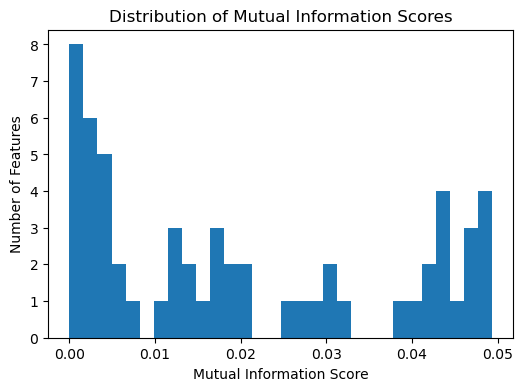

In [163]:
plt.figure(figsize=(6,4))

mi_scores.plot(
    kind="hist",
    bins=30
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Number of Features")
plt.title("Distribution of Mutual Information Scores")

plt.show()

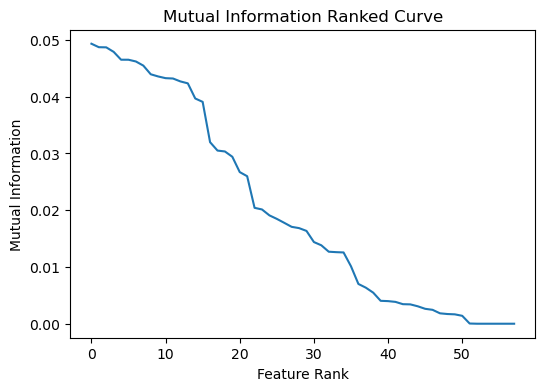

In [164]:
# Looking at the ranking curve of the MI scores
#   shows clear places where cutoffs could be made
#   Cut at 20: clear discontinuous drop
#   Cut at 25: ~ 50% MI drop
#   Cut at 40: another discontinous change
#   Cut at 60: values reach 0

plt.figure(figsize=(6,4))

mi_scores.reset_index(drop=True).plot()

plt.ylabel("Mutual Information")
plt.xlabel("Feature Rank")
plt.title("Mutual Information Ranked Curve")

plt.show()

In [165]:
HIGH_MI_THRESHOLD = 0.01

high_mi_features = mi_scores[
    mi_scores > HIGH_MI_THRESHOLD
].index.tolist()

FEATURE_KEEP += high_mi_features

print(FEATURE_KEEP)

['demogr_pop_2016', 'hous_frac_type_single_detached', 'latitude', 'socioeco_frac_nonlaborer', 'hous_frac_age_pre_1980', 'hous_median_value', 'socioeco_frac_high_income', 'longitude', 'demogr_frac_tenure_owned', 'hous_frac_major_repair', 'socioeco_frac_bachelor_plus', 'sedi_glacial_sediments', 'hous_frac_age_post_2001', 'socioeco_frac_overcrowded', 'socioeco_median_income', 'average_heating_days', 'hous_frac_type_highrise', 'mean_uranium', 'max_uranium', 'sedi_glaciolacustrine_sediments', 'socioeco_frac_housing_burden', 'socioeco_frac_govt_transfers', 'demogr_median_age', 'socioeco_frac_unemployment_rate', 'sedi_glaciofluvial_sediments', 'rxtp_intrusive_rocks', 'rxtp_volcanic_rocks', 'socioeco_frac_low_income', 'sedi_alluvial_sediments', 'sedi_glaciomarine_sediments', 'demogr_frac_tenure_band', 'sedi_bedrock', 'rxtp_sedimentary_rocks', 'rxtp_metamorphic_rocks', 'sedi_marine_sediments', 'sedi_organic_deposits']


In [166]:
len(FEATURE_DROP)

38

In [179]:

from src.data.data_loading import (
    load_training_data,
    load_validation_data
)

# Load the training and validation data
train = load_training_data(cv_fold=0)
val = load_validation_data(cv_fold=0)

# Remove everything but the good features
FEATURE_DROP += ["max_uranium", "mean_uranium"]
FEATURE_DROP_train = [c for c in FEATURE_DROP if c in train.columns]
FEATURE_DROP_val = [c for c in FEATURE_DROP if c in val.columns]
X_train = train.drop(columns=FEATURE_DROP_train)
X_val = val.drop(columns=FEATURE_DROP_val)


# Define the targets
train["radon_danger_conc"] = (train["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)
val["radon_danger_conc"] = (val["concentration"] > RADON_CONC_HEALTH_RISK).astype(int)

y_train = train["radon_danger_conc"]
y_val = val["radon_danger_conc"]

In [180]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [181]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [182]:
model.score(X_val_scaled, y_val)

0.9072015466408894

In [184]:
from sklearn.metrics import classification_report

pred = model.predict(X_val_scaled)

print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1877
           1       0.00      0.00      0.00       192

    accuracy                           0.91      2069
   macro avg       0.45      0.50      0.48      2069
weighted avg       0.82      0.91      0.86      2069



c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,